# Notebook 04 — Tree-based modellen
## Decision Tree · Random Forest · Gradient Boosting · XGBoost

**Project:** ML Regressie op YouTube trending video data  
 
**Doel van deze notebook:** Tree-based regressiemodellen trainen, tunen en vergelijken — inclusief feature importance analyse.

---

### Waarom tree-based modellen?

De modellen uit notebook 03 (lineaire regressie, Ridge, Lasso...) veronderstellen **lineaire relaties** tussen features en target.  
Maar de werkelijkheid is vaak complexer:
- Een kanaal met 1M abonnees én een korte video én in de categorie Music scoort misschien anders dan je afzonderlijk zou verwachten
- Interacties tussen features zijn niet lineair

Tree-based modellen vangen dit soort **niet-lineaire verbanden en interacties** automatisch op — zonder dat je ze expliciet moet definiëren.

## 1. Setup & data laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

import os
os.makedirs('../output/figures', exist_ok=True)
os.makedirs('../output/models', exist_ok=True)

with open('../output/models/train_test_data.pkl', 'rb') as f:
    data = pickle.load(f)

with open('../output/models/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

with open('../output/models/results_nb03.pkl', 'rb') as f:
    results = pickle.load(f)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']
feature_names = data['feature_names']

print(f'Trainset: {X_train.shape[0]} rijen × {X_train.shape[1]} features')
print(f'Testset:  {X_test.shape[0]} rijen × {X_test.shape[1]} features')
print(f'Resultaten geladen uit notebook 03: {list(results.keys())}')

Trainset: 8000 rijen × 22 features
Testset:  2000 rijen × 22 features
Resultaten geladen uit notebook 03: ['Baseline (gemiddelde)', 'Lineaire regressie', 'Polynomiale regressie (degree=2)', 'Polynomiale regressie (degree=3)', 'KNN (k=30)', 'Ridge (alpha=100.0)', 'Lasso (alpha=0.01)', 'ElasticNet (α=0.01, l1=0.7)']


## 2. Hulpfunctie

In [2]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)

    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    cv_r2 = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='r2').mean()

    results[name] = {'R²': r2, 'MAE': mae, 'RMSE': rmse, 'CV R² (train)': cv_r2}

    print(f'{name}')
    print(f'  R²             = {r2:.4f}')
    print(f'  MAE            = {mae:.4f}')
    print(f'  RMSE           = {rmse:.4f}')
    print(f'  CV R² (train)  = {cv_r2:.4f}  {"⚠️ mogelijke overfitting" if cv_r2 - r2 > 0.05 else "✓"}')
    print()
    return pipeline

print('Hulpfunctie klaar.')

Hulpfunctie klaar.


## 3. Decision Tree Regressor

**Hoe werkt het?**  
Een beslissingsboom splitst de data stap voor stap op basis van vragen:
> *"Is het abonneeaantal groter dan X? Ja → ga links. Nee → ga rechts."*

Elke splitsing kiest de feature en drempelwaarde die de **variantie** in de doelvariabele het meest reduceert.  
De bladeren (eindknopen) bevatten de gemiddelde engagement score van alle trainsamples die er terechtgekomen zijn.

**Voordelen:** visueel interpreteerbaar, geen schaling nodig  
**Nadeel:** snel overfitten bij diepe bomen — max_depth is de belangrijkste hyperparameter

In [3]:
# max_depth tunen via cross-validatie
depths = [2, 3, 4, 5, 6, 8, 10, 15, None]
depth_scores = []

for d in depths:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2').mean()
    depth_scores.append(score)
    label = str(d) if d is not None else 'None (onbeperkt)'
    print(f'  max_depth={label:<18}  CV R²={score:.4f}')

best_depth_idx = np.argmax(depth_scores)
best_depth = depths[best_depth_idx]
print(f'\nBeste max_depth: {best_depth} (CV R²={depth_scores[best_depth_idx]:.4f})')

  max_depth=2                   CV R²=0.6401


  max_depth=3                   CV R²=0.6878

  max_depth=4                   CV R²=0.6972


  max_depth=5                   CV R²=0.6909


  max_depth=6                   CV R²=0.6800


  max_depth=8                   CV R²=0.6474


  max_depth=10                  CV R²=0.6074


  max_depth=15                  CV R²=0.4956


  max_depth=None (onbeperkt)    CV R²=0.3951

Beste max_depth: 4 (CV R²=0.6972)


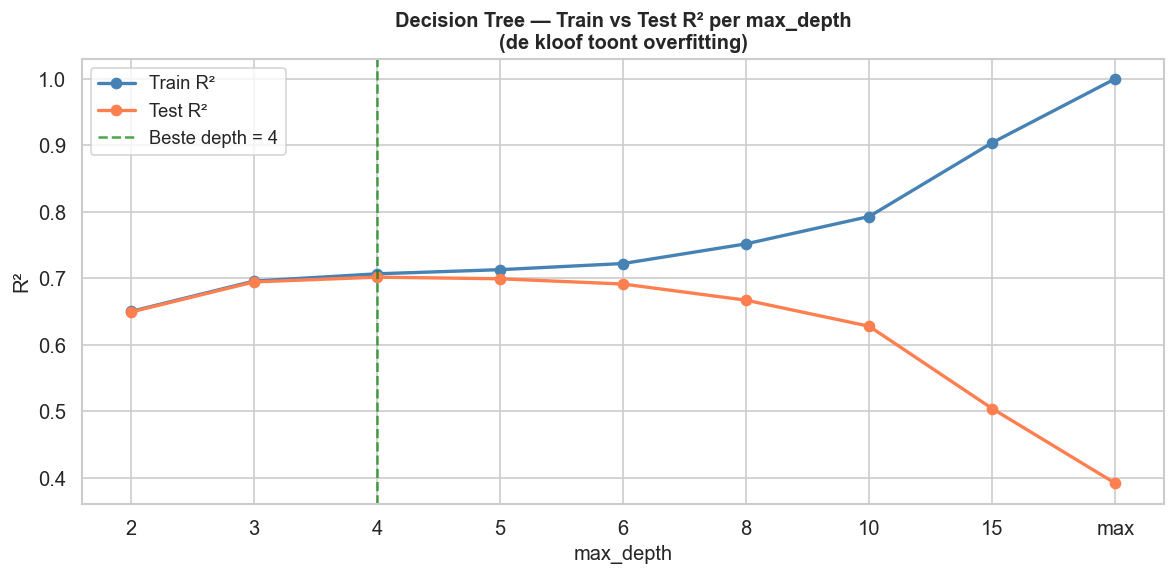

In [4]:
# Overfitting visualiseren: train vs test R² per depth
train_r2, test_r2 = [], []
depth_labels = []

for d in depths:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, pipe.predict(X_train)))
    test_r2.append(r2_score(y_test,   pipe.predict(X_test)))
    depth_labels.append(str(d) if d is not None else 'max')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depth_labels, train_r2, 'o-', color='steelblue', linewidth=2, label='Train R²')
ax.plot(depth_labels, test_r2,  'o-', color='coral',     linewidth=2, label='Test R²')
ax.axvline(str(best_depth) if best_depth is not None else 'max',
           color='green', linestyle='--', alpha=0.7, label=f'Beste depth = {best_depth}')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Decision Tree — Train vs Test R² per max_depth\n(de kloof toont overfitting)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../output/figures/04_dt_depth_curve.png')
plt.show()

In [5]:
# Beste Decision Tree trainen en evalueren
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=best_depth, random_state=42))
])
dt_pipe = evaluate_model(f'Decision Tree (depth={best_depth})',
                         dt_pipe, X_train, y_train, X_test, y_test)

Decision Tree (depth=4)
  R²             = 0.7018
  MAE            = 0.9311
  RMSE           = 1.2540
  CV R² (train)  = 0.6972  ✓



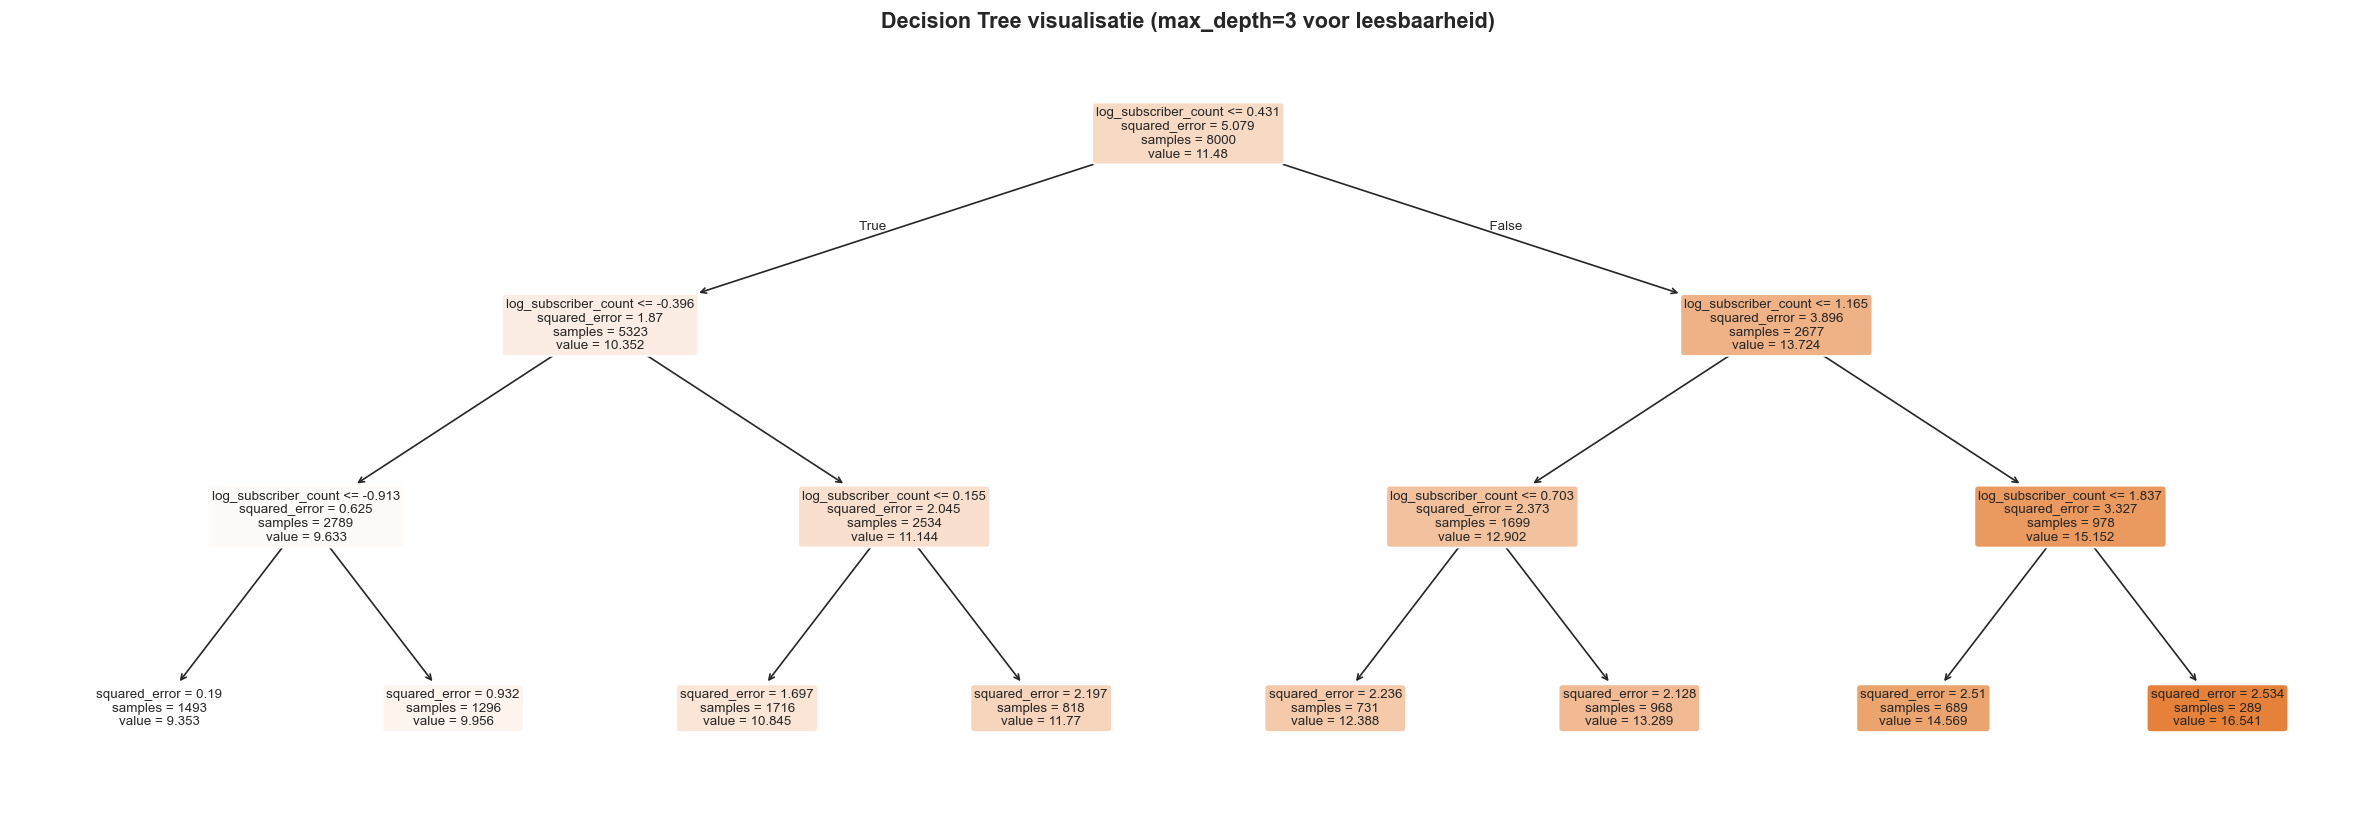

De boom toont welke vragen het model stelt om engagement te voorspellen.


In [6]:
# Eerste lagen van de boom visualiseren (max depth=3 voor leesbaarheid)
dt_viz_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=3, random_state=42))
])
dt_viz_pipe.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(
    dt_viz_pipe.named_steps['model'],
    feature_names=feature_names,
    filled=True, rounded=True, fontsize=8, ax=ax
)
ax.set_title('Decision Tree visualisatie (max_depth=3 voor leesbaarheid)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/04_dt_visualisatie.png')
plt.show()
print('De boom toont welke vragen het model stelt om engagement te voorspellen.')

## 4. Random Forest Regressor

**Hoe werkt het?**  
Een Random Forest bouwt **honderden beslissingsbomen** parallel, elk op een willekeurige subset van de traindata en features.  
De uiteindelijke voorspelling is het **gemiddelde** van alle bomen.

Dit principe heet **ensemble learning** — de gecombineerde wijsheid van vele zwakkere modellen overtreft één sterk model.

Twee sleutelparameters:
- **n_estimators**: aantal bomen — meer is beter, tot een plateau
- **max_depth**: diepte van elke individuele boom

Random Forest is ook robuust tegen overfitting dankzij de randomisatie.

  n_estimators=10     CV R²=0.6633


  n_estimators=25     CV R²=0.6780


  n_estimators=50     CV R²=0.6837


  n_estimators=100    CV R²=0.6863


  n_estimators=200    CV R²=0.6879


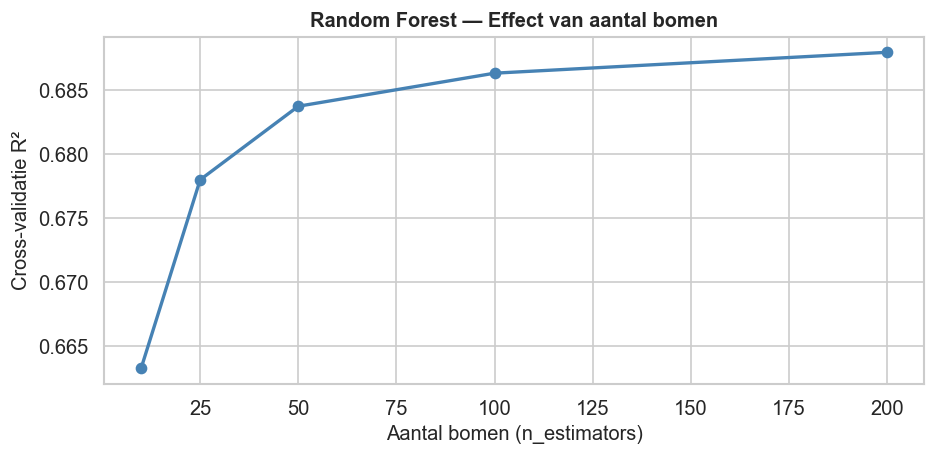

In [7]:
# Effect van n_estimators visualiseren
n_estimators_range = [10, 25, 50, 100, 200]
rf_cv_scores = []

for n in n_estimators_range:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1))
    ])
    score = cross_val_score(pipe, X_train, y_train, cv=3, scoring='r2').mean()
    rf_cv_scores.append(score)
    print(f'  n_estimators={n:<5}  CV R²={score:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimators_range, rf_cv_scores, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Aantal bomen (n_estimators)', fontsize=12)
ax.set_ylabel('Cross-validatie R²', fontsize=12)
ax.set_title('Random Forest — Effect van aantal bomen', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/04_rf_n_estimators.png')
plt.show()

In [8]:
# Hyperparameter tuning via RandomizedSearchCV
param_dist_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth':    [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}

rf_base_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_search = RandomizedSearchCV(
    rf_base_pipe, param_dist_rf,
    n_iter=15, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

print(f'\nBeste parameters: {rf_search.best_params_}')
print(f'Beste CV R²:      {rf_search.best_score_:.4f}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits



Beste parameters: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__max_features': 'sqrt', 'model__max_depth': 30}
Beste CV R²:      0.6891


In [9]:
# Beste Random Forest evalueren
best_rf_pipe = rf_search.best_estimator_
best_rf_pipe = evaluate_model('Random Forest (getuned)', best_rf_pipe,
                              X_train, y_train, X_test, y_test)

Random Forest (getuned)
  R²             = 0.6996
  MAE            = 0.9500
  RMSE           = 1.2588
  CV R² (train)  = 0.6894  ✓



## 5. Gradient Boosting Regressor

**Hoe werkt het?**  
Gradient Boosting bouwt bomen **sequentieel**: elke nieuwe boom leert van de fouten van de vorige.

Stel dat boom 1 een fout maakt van +0.5 voor een bepaalde video — boom 2 zal zich focussen op het corrigeren van die fout.  
Dit stapelen van correcties maakt Gradient Boosting vaak krachtiger dan Random Forest.

**Belangrijke parameters:**
- **n_estimators**: aantal opeenvolgende bomen
- **learning_rate**: hoe groot elke correctiestap is (kleiner = stabieler maar trager)
- **max_depth**: diepte per boom (typisch klein: 3–5)

In [10]:
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        random_state=42
    ))
])
gb_pipe = evaluate_model('Gradient Boosting', gb_pipe, X_train, y_train, X_test, y_test)

Gradient Boosting
  R²             = 0.6993
  MAE            = 0.9398
  RMSE           = 1.2594
  CV R² (train)  = 0.6876  ✓



## 6. XGBoost

**Hoe werkt het?**  
XGBoost (eXtreme Gradient Boosting) is een geoptimaliseerde implementatie van Gradient Boosting.  
Het is aanzienlijk sneller, gebruikt minder geheugen, en heeft ingebouwde regularisatie (L1 + L2).

XGBoost is al jaren een van de best presterende algoritmen voor gestructureerde data — het wint consistent Kaggle-competities.

In [11]:
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        nthread=1
    ))
])
xgb_pipe = evaluate_model('XGBoost', xgb_pipe, X_train, y_train, X_test, y_test)

XGBoost
  R²             = 0.6997
  MAE            = 0.9441
  RMSE           = 1.2584
  CV R² (train)  = 0.6851  ✓



In [12]:
# XGBoost hyperparameter tuning
param_dist_xgb = {
    'model__n_estimators':     [200, 300, 500],
    'model__learning_rate':    [0.01, 0.05, 0.1],
    'model__max_depth':        [3, 4, 5, 6],
    'model__subsample':        [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_base_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, verbosity=0, nthread=1))
])

xgb_search = RandomizedSearchCV(
    xgb_base_pipe, param_dist_xgb,
    n_iter=15, cv=3, scoring='r2',
    random_state=42, n_jobs=1, verbose=1
)
xgb_search.fit(X_train, y_train)

print(f'\nBeste parameters: {xgb_search.best_params_}')
print(f'Beste CV R²:      {xgb_search.best_score_:.4f}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits



Beste parameters: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}
Beste CV R²:      0.6996


In [13]:
best_xgb_pipe = xgb_search.best_estimator_
best_xgb_pipe = evaluate_model('XGBoost (getuned)', best_xgb_pipe,
                               X_train, y_train, X_test, y_test)

XGBoost (getuned)
  R²             = 0.7091
  MAE            = 0.9409
  RMSE           = 1.2386
  CV R² (train)  = 0.6989  ✓



## 7. Feature importance

Een groot voordeel van tree-based modellen: ze berekenen automatisch **feature importance** —  
hoe vaak en hoe nuttig een feature was bij het maken van splitsingen.

Dit geeft ons een direct antwoord op de onderzoeksvraag:  
> *Welke factoren bepalen of een video hoog scoort op engagement?*

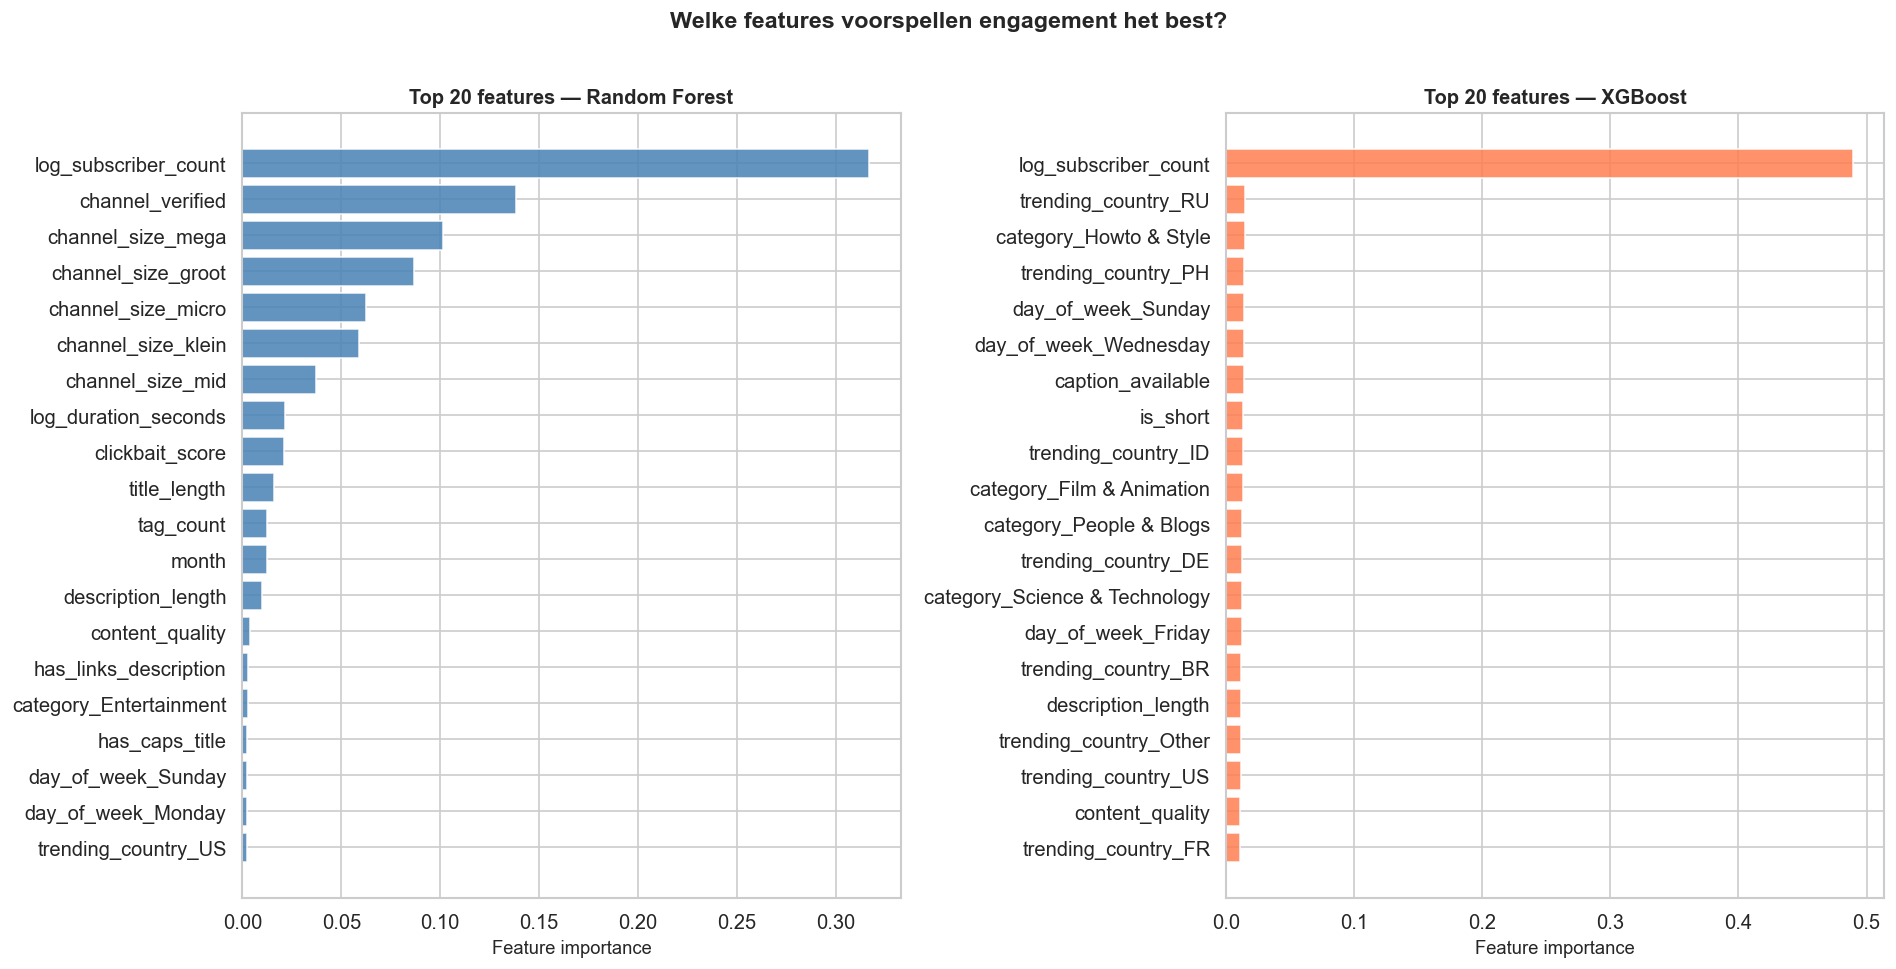

In [14]:
# Feature importance vergelijken: Random Forest vs XGBoost
best_rf_pipe.fit(X_train, y_train)
best_xgb_pipe.fit(X_train, y_train)

rf_importance  = best_rf_pipe.named_steps['model'].feature_importances_
xgb_importance = best_xgb_pipe.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature':      feature_names,
    'Random Forest': rf_importance,
    'XGBoost':       xgb_importance
})
importance_df['Gemiddeld'] = importance_df[['Random Forest', 'XGBoost']].mean(axis=1)
top20_imp = importance_df.nlargest(20, 'Gemiddeld').sort_values('Gemiddeld', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, col, color in zip(axes, ['Random Forest', 'XGBoost'], ['steelblue', 'coral']):
    top = importance_df.nlargest(20, col).sort_values(col, ascending=True)
    ax.barh(top['feature'], top[col], color=color, alpha=0.85)
    ax.set_xlabel('Feature importance', fontsize=11)
    ax.set_title(f'Top 20 features — {col}', fontsize=12, fontweight='bold')

plt.suptitle('Welke features voorspellen engagement het best?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/figures/04_feature_importance.png')
plt.show()

In [15]:
# Gecombineerde top 10 features
top10 = importance_df.nlargest(10, 'Gemiddeld')[['feature', 'Random Forest', 'XGBoost', 'Gemiddeld']]
print('Top 10 meest voorspellende features (gemiddeld over RF en XGBoost):')
display(top10.round(4))

Top 10 meest voorspellende features (gemiddeld over RF en XGBoost):


,feature,Random Forest,XGBoost,Gemiddeld
5,log_subscriber_count,0.3168,0.4895,0.4032
70,channel_verified,0.1382,0.0000,0.0691
57,channel_size_mega,0.1014,0.0000,0.0507
55,channel_size_groot,0.0870,0.0000,0.0435
56,channel_size_klein,0.0589,0.0061,0.0325
58,channel_size_micro,0.0624,0.0000,0.0312
59,channel_size_mid,0.0374,0.0000,0.0187
6,log_duration_seconds,0.0215,0.0107,0.0161
4,clickbait_score,0.0212,0.0092,0.0152
0,title_length,0.0162,0.0100,0.0131


## 8. Learning curves — is er nog ruimte voor verbetering?

Een **learning curve** toont hoe de prestatie evolueert naarmate er meer traindata beschikbaar is.  
- Als train- en validatiescore convergeren bij meer data → het model heeft baat bij meer data  
- Als de kloof groot blijft → het model heeft baat bij meer tuning of andere features

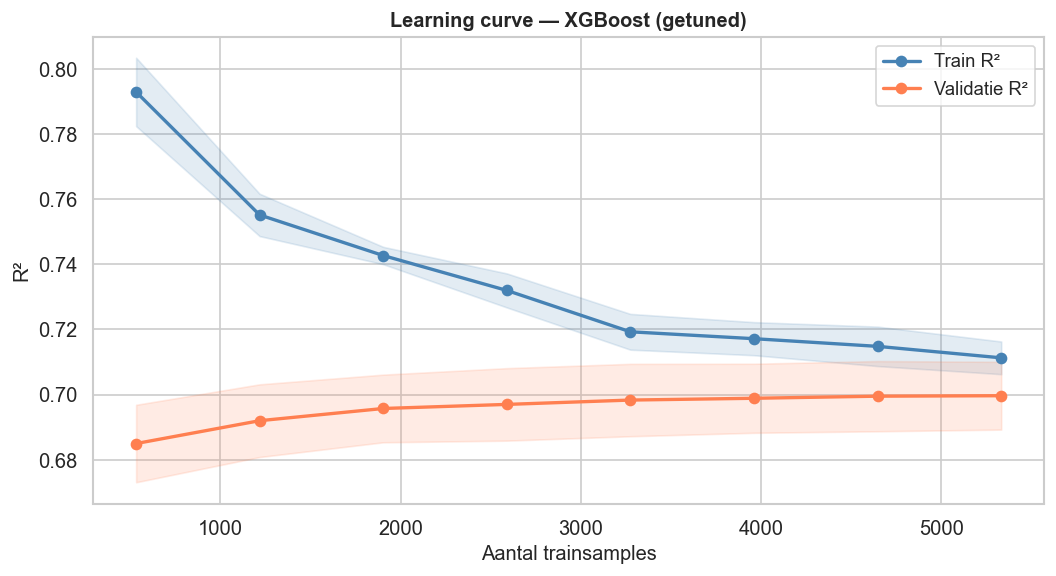

In [16]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_xgb_pipe, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='r2', n_jobs=1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train R²', linewidth=2)
ax.plot(train_sizes, val_mean,   'o-', color='coral',     label='Validatie R²', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
ax.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='coral')
ax.set_xlabel('Aantal trainsamples', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Learning curve — XGBoost (getuned)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../output/figures/04_learning_curve_xgb.png')
plt.show()

## 9. Vergelijking tree-based modellen

In [17]:
tree_models = ['Decision Tree (depth={})'.format(best_depth),
               'Random Forest (getuned)', 'Gradient Boosting',
               'XGBoost', 'XGBoost (getuned)']

tree_results = {k: v for k, v in results.items() if any(m in k for m in
                ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost'])}

tree_df = pd.DataFrame(tree_results).T.round(4).sort_values('R²', ascending=False)
print('Vergelijking tree-based modellen:')
display(tree_df)

Vergelijking tree-based modellen:


,R²,MAE,RMSE,CV R² (train)
XGBoost (getuned),0.7091,0.9409,1.2386,0.6989
Decision Tree (depth=4),0.7018,0.9311,1.2540,0.6972
XGBoost,0.6997,0.9441,1.2584,0.6851
Random Forest (getuned),0.6996,0.9500,1.2588,0.6894
Gradient Boosting,0.6993,0.9398,1.2594,0.6876


In [18]:
# Resultaten opslaan voor notebook 05
with open('../output/models/results_nb04.pkl', 'wb') as f:
    pickle.dump(results, f)

# Beste model opslaan
with open('../output/models/best_xgb_pipe.pkl', 'wb') as f:
    pickle.dump(best_xgb_pipe, f)

with open('../output/models/best_rf_pipe.pkl', 'wb') as f:
    pickle.dump(best_rf_pipe, f)

print('Resultaten en modellen opgeslagen.')

Resultaten en modellen opgeslagen.


## 10. Samenvatting

| Model | Kernidee | Sterk punt |
|---|---|---|
| **Decision Tree** | Stel ja/nee-vragen over features | Visueel interpreteerbaar |
| **Random Forest** | Gemiddelde van 100+ bomen | Robuust, weinig tuning nodig |
| **Gradient Boosting** | Elke boom corrigeert de vorige | Hoge nauwkeurigheid |
| **XGBoost** | Geoptimaliseerde Gradient Boosting | Snel, krachtig, ingebouwde regularisatie |

**Kernbevinding feature importance:**  
De meest voorspellende features voor `engagement_score` worden zichtbaar via de importance scores.  
Dit geeft een direct antwoord op de onderzoeksvraag — te bespreken in notebook 05.

---

**Volgende stap:** Notebook 05 — Eindvergelijking van alle modellen en conclusies